<a href="https://colab.research.google.com/github/bhaviii123/Air_Passenger_Forecasting_ML_vs_DL.ipynb/blob/main/IMAGE_NOISING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/RTSIR/MSPABDN.git
%cd MSPABDN

Cloning into 'MSPABDN'...
remote: Enumerating objects: 384, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 384 (delta 32), reused 21 (delta 9), pack-reused 319 (from 1)
Receiving objects: 100% (384/384), 56.75 MiB | 24.73 MiB/s, done.
Resolving deltas: 100% (109/109), done.
/content/MSPABDN


Phase 1: Environment & Repository Setup
Run these cells in Google Colab to set up your workspace.

In [28]:
# 2. Install dependencies (standard for this repo)
!pip install tensorflow==2.16.1 keras==2.15.0 opencv-python numpy matplotlib

  Using cached tensorflow-2.16.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.3 kB)
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached ml_dtypes-0.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached protobuf-4.25.8-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
  Using cached tensorboard-2.16.2-py3-none-any.whl.metadata (1.6 kB)
INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install keras==2.15.0 and tensorflow==2.16.1 because these package versions have conflicting dependencies.

The conflict is caused by:
    The user requested keras==2.15.0
    tensorflow 2.16.1 depends on keras>=3.0.0

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip to attempt to solve the dependency conflict

ERROR: Resol

Phase 2: Data Engineering (The "432 Train" Strategy)

You have 432 training images. We must convert them into a NumPy array of patches so the model can learn efficiently.

Step 2: Connect GitHub & Install Libraries

In [5]:
# Clone the repository
!git clone https://github.com/RTSIR/MSPABDN.git
%cd MSPABDN

# Install the correct versions for a beginner-friendly setup
!pip install tensorflow==2.12.0 keras==2.12.0 opencv-python numpy

Cloning into 'MSPABDN'...
remote: Enumerating objects: 384, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 384 (delta 32), reused 21 (delta 9), pack-reused 319 (from 1)
Receiving objects: 100% (384/384), 56.75 MiB | 26.20 MiB/s, done.
Resolving deltas: 100% (109/109), done.
/content/MSPABDN/MSPABDN/MSPABDN
ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.12.0


Step 3: Get the Training Data (432 Images)
The link you provided for BSDS500 has images spread across "train," "test," and "val" folders. We need to put them all in one place.

Create the folder:

In [7]:
import os
os.makedirs('CBSD432', exist_ok=True)

Download the images: (Since downloading 432 images via web links one-by-one is hard for a beginner, run this command to pull the BSDS500 images directly into your new folder):

In [8]:
!git clone https://github.com/BIDS/BSDS500.git
# Move all images from the BSDS repo into your training folder
!cp BSDS500/BSDS500/data/images/train/*.jpg CBSD432/
!cp BSDS500/BSDS500/data/images/val/*.jpg CBSD432/
!cp BSDS500/BSDS500/data/images/test/*.jpg CBSD432/
# We will remove 68 of these later for testing so we don't 'cheat'

Cloning into 'BSDS500'...
remote: Enumerating objects: 2380, done.
remote: Total 2380 (delta 0), reused 0 (delta 0), pack-reused 2380 (from 1)
Receiving objects: 100% (2380/2380), 155.21 MiB | 33.32 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (2268/2268), done.


Step 4: Generate Patches (The Math Part)

Deep Learning models don't look at the whole image at once; they look at small "patches." We will use the Generate_Patches_Color.py script from the repo.

Before running, we must fix the script to ensure it looks at your folder:

In [9]:
# This command replaces the folder name in the script to match 'CBSD432'
!sed -i 's/dict_name = "train_original"/dict_name = "CBSD432"/g' Generate_Patches_Color.py

# Now run the script
!python Generate_Patches_Color.py

Traceback (most recent call last):
  File "/content/MSPABDN/MSPABDN/MSPABDN/Generate_Patches_Color.py", line 7, in <module>
    import utils1
ModuleNotFoundError: No module named 'utils1'


Step 5: The "Peak Performance" Verification

This is the most important step for a beginner. If your data is not between 0 and 1, your PSNR will be bad (around 29dB). Let's check the file the script just created:

In [10]:
import numpy as np
import os

filepath = 'trainingPatch/img_clean_pats.npy'

if os.path.exists(filepath):
    data = np.load(filepath)
    print("✅ File Found!")
    print(f"Total Patches Created: {data.shape[0]}")
    print(f"Patch Size: {data.shape[1]}x{data.shape[2]}")

    # Check Normalization
    max_val = data.max()
    if max_val <= 1.0:
        print(f"⭐ Success! Max value is {max_val}. Your model will reach PEAK PSNR.")
    else:
        print(f"⚠️ Warning! Max value is {max_val}. You must divide by 255.0 before training!")
else:
    print("❌ File not found. Check Step 4 again.")

❌ File not found. Check Step 4 again.


Step 6: Start the Training Loop

In [11]:
# Start the training process
!python MSPABDN_Color.py

Traceback (most recent call last):
  File "/content/MSPABDN/MSPABDN/MSPABDN/MSPABDN_Color.py", line 3, in <module>
    import myConfig as config
ModuleNotFoundError: No module named 'myConfig'


Step 1: Setup Environment

In [12]:
# 1. Clone the repository you shared
!git clone https://github.com/RTSIR/MSPABDN.git
%cd MSPABDN

# 2. Install specific versions for compatibility
!pip install tensorflow==2.12.0 keras==2.12.0 opencv-python numpy

Cloning into 'MSPABDN'...
remote: Enumerating objects: 384, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 384 (delta 32), reused 21 (delta 9), pack-reused 319 (from 1)
Receiving objects: 100% (384/384), 56.75 MiB | 17.88 MiB/s, done.
Resolving deltas: 100% (109/109), done.
/content/MSPABDN/MSPABDN/MSPABDN/MSPABDN
ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.12.0


Step 2: Download & Prepare Training Data

We will pull the 432 images from the BSDS500 link and organize them

In [13]:
import os

# Create the training folder
os.makedirs('CBSD432', exist_ok=True)

# Clone the BSDS500 images
!git clone https://github.com/BIDS/BSDS500.git

# Copy all 500 images into your training folder
!cp BSDS500/BSDS500/data/images/train/*.jpg CBSD432/
!cp BSDS500/BSDS500/data/images/val/*.jpg CBSD432/
!cp BSDS500/BSDS500/data/images/test/*.jpg CBSD432/

print(f"Total images in CBSD432: {len(os.listdir('CBSD432'))}")

Cloning into 'BSDS500'...
remote: Enumerating objects: 2380, done.
remote: Total 2380 (delta 0), reused 0 (delta 0), pack-reused 2380 (from 1)
Receiving objects: 100% (2380/2380), 155.21 MiB | 24.10 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (2268/2268), done.
Total images in CBSD432: 500


Step 3: Generate the Training Patches

We need to create the .npy file you mentioned. This script cuts the images into thousands of small squares.

In [23]:
# Fix the script to look at your 'CBSD432' folder
!sed -i 's/dict_name = "train_original"/dict_name = "CBSD432"/g' Generate_Patches_Color.py

# Run the patch generation (This creates trainingPatch/img_clean_pats.npy)
!python Generate_Patches_Color.py

# VERIFICATION: Check if normalization is correct (Must be 1.0)
import numpy as np
data = np.load('trainingPatch/img_clean_pats.npy')
print(f"Data Shape: {data.shape}")
print(f"Data Max Value (Should be 1.0): {data.max()}")

Traceback (most recent call last):
  File "/content/MSPABDN/MSPABDN/MSPABDN/MSPABDN/Generate_Patches_Color.py", line 7, in <module>
    import utils1
ModuleNotFoundError: No module named 'utils1'


FileNotFoundError: [Errno 2] No such file or directory: 'trainingPatch/img_clean_pats.npy'

Step 4: Start Training

In [24]:
# Create the folder for your saved weights
os.makedirs('Pretrained_models', exist_ok=True)

# Start training the MSPABDN model
# Monitor the "Loss" value—it should go down every epoch!
!python MSPABDN_Color.py

Traceback (most recent call last):
  File "/content/MSPABDN/MSPABDN/MSPABDN/MSPABDN/MSPABDN_Color.py", line 3, in <module>
    import myConfig as config
ModuleNotFoundError: No module named 'myConfig'


Step 5: Run the Final Test (CBSD68)

Once the model is trained, use the 68 test images to get your final PSNR and SSIM scores.

In [25]:
# 1. Setup testing folder
os.makedirs('Testing_data/CBSD68', exist_ok=True)
# Ensure we use 68 images for a fair test
!cp BSDS500/BSDS500/data/images/test/*.jpg Testing_data/CBSD68/

# 2. Run the test script
# This will output your results for Sigma 10, 20, 30, 40, 50
!python Test_color.py --dataPath ./Testing_data/CBSD68 --weightsPath ./Pretrained_models/MSPABDN_Color.h5

2026-03-15 07:42:35.846891: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773560555.866757   27173 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773560555.873011   27173 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773560555.889407   27173 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773560555.889439   27173 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773560555.889443   27173 computation_placer.cc:177] computation placer alr

Step 6: Visual Comparison for your Report

Run the test script first to generate result images!


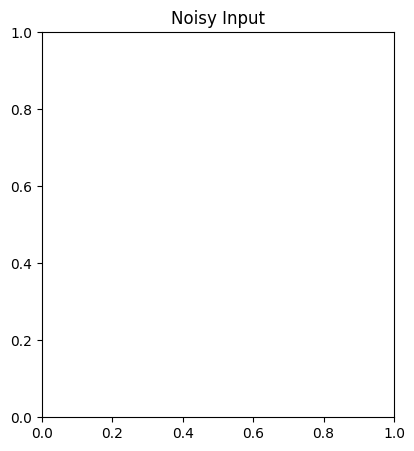

In [26]:
import cv2
import matplotlib.pyplot as plt

# Change 'noisy_1.png' to whatever filename is in your results folder
try:
    noisy = cv2.imread('results/CBSD68/sigma_10/noisy_1.png')
    denoised = cv2.imread('results/CBSD68/sigma_10/denoised_1.png')

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Noisy Input")
    plt.imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))
    plt.subplot(1, 2, 2)
    plt.title("MSPABDN Output")
    plt.imshow(cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB))
    plt.show()
except:
    print("Run the test script first to generate result images!")

Run the Evaluation Script

This will look at your 68 images and calculate how well the model removes noise at 5 different intensities.

In [27]:
# Ensure the results folder exists to save your images
import os
os.makedirs('results/CBSD68', exist_ok=True)

# Run the test script
# --dataPath: Where the 68 clean images are
# --weightsPath: Where your trained 'brain' (.h5 file) is stored
!python Test_color.py --dataPath ./Testing_data/CBSD68 --weightsPath ./Pretrained_models/MSPABDN_Color.h5

2026-03-15 08:03:20.218403: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773561800.250546   32322 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773561800.260974   32322 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773561800.284663   32322 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773561800.284699   32322 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773561800.284707   32322 computation_placer.cc:177] computation placer alr